<a href="https://colab.research.google.com/github/PratapPawarGit/Data-Science/blob/main/RNN_DailyEnergy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# load the uploaded file
import pandas as pd
uploaded_data = pd.read_csv('daily_energy_consumption.csv')
uploaded_data.head()


,Date,Consumption (kWh),Temperature (°C),Humidity (%)
0,01-01-2021,3547,18.90,39.34
1,02-01-2021,3947,8.05,50.24
2,03-01-2021,4959,26.60,88.63
3,04-01-2021,3813,8.98,24.73
4,05-01-2021,3583,17.08,56.31


In [ ]:
uploaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               730 non-null    object 
 1   Consumption (kWh)  730 non-null    int64  
 2   Temperature (°C)   730 non-null    float64
 3   Humidity (%)       730 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 22.9+ KB


In [ ]:
# Convert 'Date' column to datetime, specifying the correct format
uploaded_data['Date'] = pd.to_datetime(uploaded_data['Date'], format='%d-%m-%Y') # specify format as day-month-year

In [ ]:
uploaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               730 non-null    datetime64[ns]
 1   Consumption (kWh)  730 non-null    int64         
 2   Temperature (°C)   730 non-null    float64       
 3   Humidity (%)       730 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 22.9 KB


In [ ]:
# Set Date as index for easier plotting
uploaded_data.set_index('Date', inplace=True)
uploaded_data.head()

,Consumption (kWh),Temperature (°C),Humidity (%)
Date,,,
2021-01-01,3547,18.90,39.34
2021-01-02,3947,8.05,50.24
2021-01-03,4959,26.60,88.63
2021-01-04,3813,8.98,24.73
2021-01-05,3583,17.08,56.31


**Step 1: Visualize Daily Energy Consumption Trend**

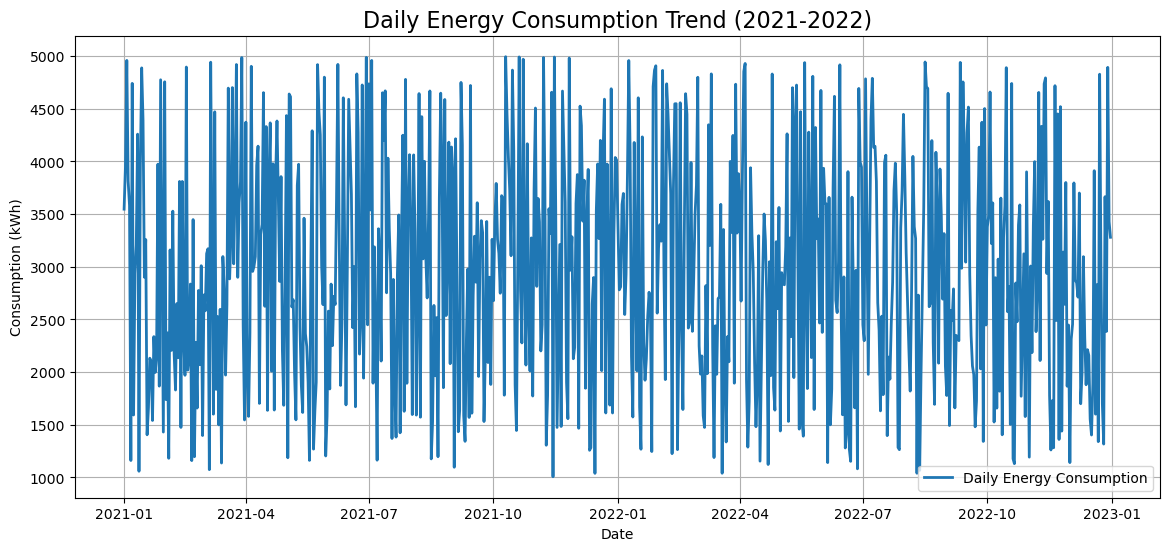

In [ ]:
# Plot the daily energy consumption
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(uploaded_data['Consumption (kWh)'], label='Daily Energy Consumption', linewidth=2)
plt.title('Daily Energy Consumption Trend (2021-2022)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()


**Step 2: Prepare Data for RNN Model**
Now we'll prepare the dataset:

*   Select only the **Consumption (kWh)** as the feature.

*   **Normalize** the values (important for RNNs).

*   **Create sequences** (past 30 days → predict next day).





In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use only 'Consumption (kWh)' for forecasting
consumption_data = uploaded_data[['Consumption (kWh)']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
consumption_scaled = scaler.fit_transform(consumption_data)

# Prepare sequences (last 30 days --> predict next day)
X = []
y = []
n_steps = 10

for i in range(n_steps, len(consumption_scaled)):
    X.append(consumption_scaled[i-n_steps:i, 0])
    y.append(consumption_scaled[i, 0])

X, y = np.array(X), np.array(y)

X.shape, y.shape


((720, 10), (720,))


**Step 3: Explore Seasonality (Monthly Patterns)**

Now, let's quickly explore seasonality —

👉 Check how the average monthly consumption varied over the 2 years!

C:\Users\ExcelR Trainers\AppData\Local\Temp\ipykernel_21320\1703996508.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = uploaded_data['Consumption (kWh)'].resample('M').mean()


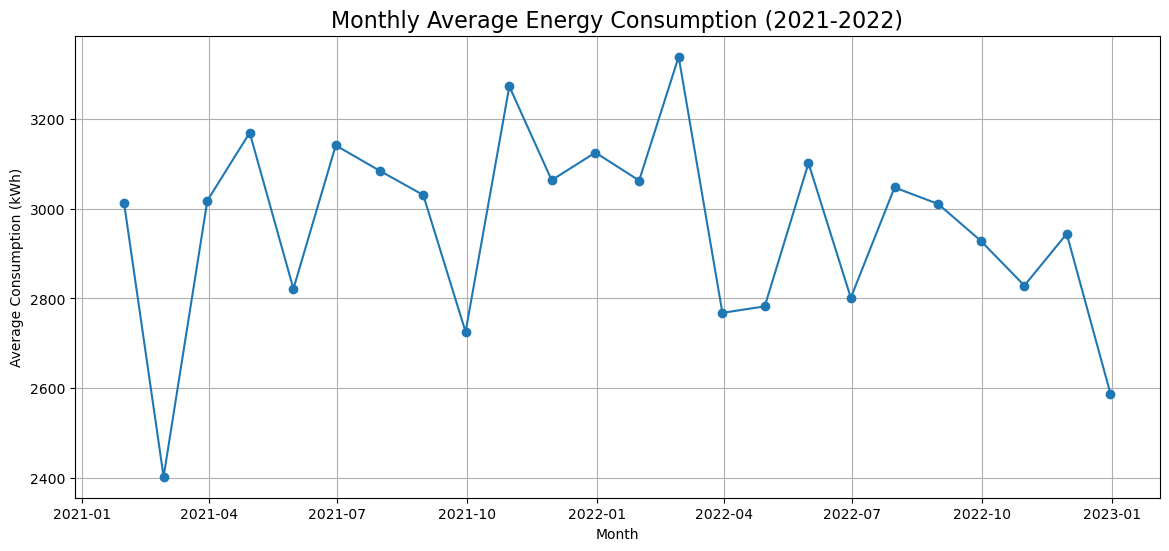

In [ ]:
# Resample to monthly frequency and calculate the mean
monthly_avg = uploaded_data['Consumption (kWh)'].resample('M').mean()

# Plot
plt.figure(figsize=(14,6))
plt.plot(monthly_avg, marker='o', linestyle='-')
plt.title('Monthly Average Energy Consumption (2021-2022)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Consumption (kWh)')
plt.grid(True)
plt.show()


Here’s the Monthly Average Energy Consumption plot!

📊 You can observe the seasonality effect — for example:

*   Some months have higher consumption (likely summer or winter due to cooling/heating).

*   Some months show lower usage.


This pattern is exactly why models like **RNNs** are important — they learn these time-based dependencies automatically!

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# Build RNN Model
model = Sequential()
model.add(SimpleRNN(50, activation='tanh', input_shape=(X.shape[1], 1)))
model.add(Dense(1))


C:\Users\ExcelR Trainers\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse')

In [ ]:
# Train Model
history = model.fit(X, y, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0990 - val_loss: 0.0850
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0802 - val_loss: 0.0814
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0806 - val_loss: 0.0808
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0799 - val_loss: 0.0818
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0792 - val_loss: 0.0788
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0776 - val_loss: 0.0787
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0773 - val_loss: 0.0924
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0831 - val_loss: 0.0789
Epoch 9/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0797 - val_loss: 0.0889
Epoch 10/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0815 - val_loss: 0.0790
Epoch 11/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0802 - val_loss: 0.0812
Epoch 12/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

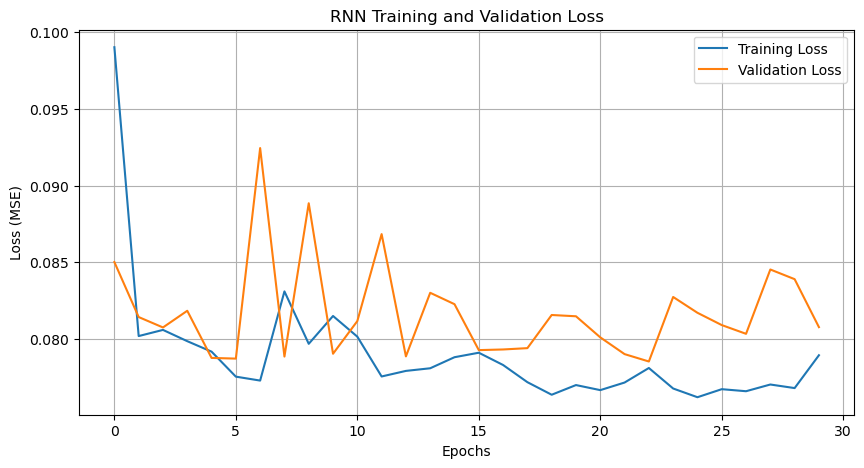

In [ ]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Example: Predict next day's consumption
last_30_days = consumption_scaled[-10:]
last_30_days = last_30_days.reshape((1, n_steps, 1))

predicted_scaled = model.predict(last_30_days)
predicted_kwh = scaler.inverse_transform(predicted_scaled)

print(f"Predicted next day's consumption: {predicted_kwh[0][0]:.2f} kWh")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Predicted next day's consumption: 3219.59 kWh


In [ ]:
predicted_kwh

array([[3219.5874]], dtype=float32)

In [ ]:
import numpy as np

test = np.array([3600,1200,4500,3600,8900,
                 4500,4500,3600,8900,4500])

# Scale
test_scaled = scaler.transform(test.reshape(-1,1))

# Reshape for RNN
test_scaled = test_scaled.reshape((1, 10, 1))

# Predict
pred_scaled = model.predict(test_scaled)

# Inverse transform
pred = scaler.inverse_transform(pred_scaled)

# Remove negatives
pred = np.maximum(pred, 0)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


C:\Users\ExcelR Trainers\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


[[2380.328]]
